# 📊 EDA — House Rent Prediction Dataset
**Лабораторна робота №1 | MLOps**

Первинний аналіз датасету оренди нерухомості (10M записів, 40 міст Індії).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Завантаження даних
Через великий розмір файлу (~1.2 GB) завантажуємо чанками і зберігаємо вибірку для EDA.

In [4]:
DATASET_PATH = '../data/raw/House_Rent_10M_balanced_40cities.csv'
SAMPLE_SIZE = 100_000  # Кількість рядків для EDA

# Завантаження вибірки
df = pd.read_csv(DATASET_PATH, nrows=SAMPLE_SIZE)
print(f'Shape: {df.shape}')
df.head()

Shape: (100000, 15)


,Property ID,Building Type,Year Built,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,Th50000000,Apartment,1990,2022-04-20,2,15266,993,4 out of 12,Built Area,Area 870,Ghaziabad,Furnished,Bachelors,1,Contact Owner
1,Th50000001,Apartment,1996,2022-07-04,1,15066,823,8 out of 5,Built Area,Area 150,Meerut,Semi-Furnished,Bachelors,1,Contact Agent
2,Th50000002,Apartment,2015,2022-04-10,3,12474,727,9 out of 8,Carpet Area,Area 274,Vijayawada,Unfurnished,Family,3,Contact Owner
3,Th50000003,Apartment,2014,2022-05-25,2,11255,1072,5 out of 8,Plot Area,Area 987,Faridabad,Furnished,Bachelors,1,Contact Agent
4,Th50000004,Apartment,1993,2022-06-03,2,18937,1293,3 out of 12,Super Area,Area 655,Jodhpur,Semi-Furnished,Family,1,Contact Owner


## 2. Базова інформація про датасет

In [5]:
print('=== ТИПИ ДАНИХ ТА ПРОПУСКИ ===')
df.info()

print('\n=== ПРОПУЩЕНІ ЗНАЧЕННЯ ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Count': missing, 'Percent %': missing_pct}).query('Count > 0'))

=== ТИПИ ДАНИХ ТА ПРОПУСКИ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Property ID        100000 non-null  object
 1   Building Type      100000 non-null  object
 2   Year Built         100000 non-null  int64 
 3   Posted On          100000 non-null  object
 4   BHK                100000 non-null  int64 
 5   Rent               100000 non-null  int64 
 6   Size               100000 non-null  int64 
 7   Floor              100000 non-null  object
 8   Area Type          100000 non-null  object
 9   Area Locality      100000 non-null  object
 10  City               100000 non-null  object
 11  Furnishing Status  100000 non-null  object
 12  Tenant Preferred   100000 non-null  object
 13  Bathroom           100000 non-null  int64 
 14  Point of Contact   100000 non-null  object
dtypes: int64(5), object(10)
memory usage: 

In [6]:
print('=== СТАТИСТИКА ЧИСЛОВИХ КОЛОНОК ===')
df.describe()

=== СТАТИСТИКА ЧИСЛОВИХ КОЛОНОК ===


,Year Built,BHK,Rent,Size,Bathroom
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2005.485860,2.002760,11890.809300,950.078300,2.002470
std,9.226262,0.817386,5364.400943,259.834236,0.815764
min,1990.000000,1.000000,2542.000000,500.000000,1.000000
25%,1997.000000,1.000000,7670.000000,726.000000,1.000000
50%,2005.000000,2.000000,10988.000000,950.000000,2.000000
75%,2013.000000,3.000000,15439.000000,1175.000000,3.000000
max,2021.000000,3.000000,27979.000000,1400.000000,3.000000


## 3. Аналіз цільової змінної — Rent

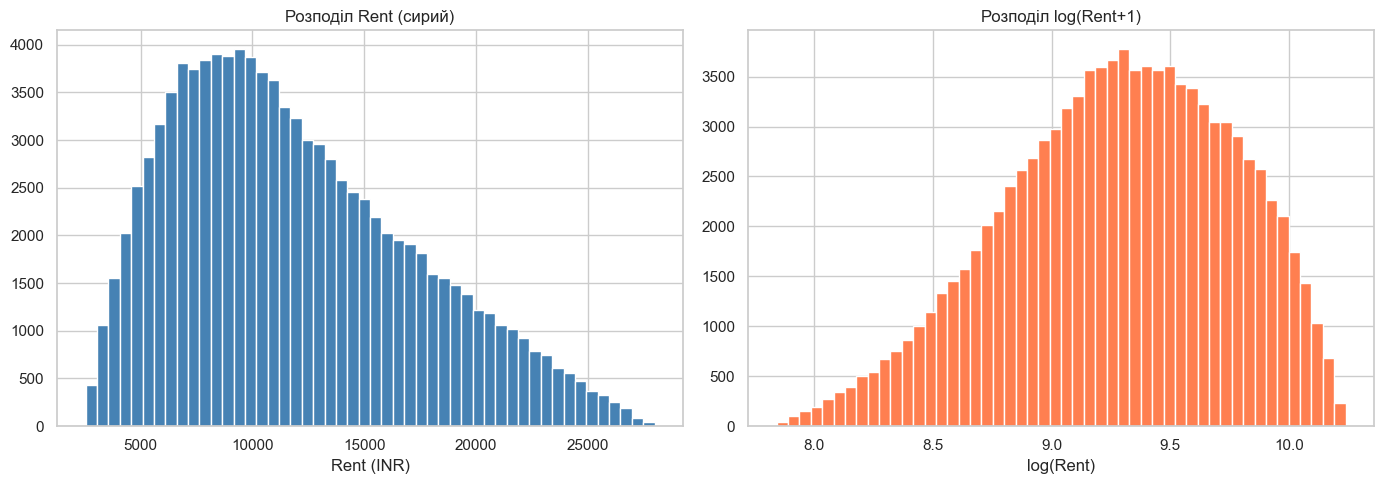

Median Rent: 10,988 INR | Mean: 11,891 INR


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Розподіл Rent
axes[0].hist(df['Rent'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Розподіл Rent (сирий)')
axes[0].set_xlabel('Rent (INR)')

# Log-розподіл
axes[1].hist(np.log1p(df['Rent']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Розподіл log(Rent+1)')
axes[1].set_xlabel('log(Rent)')

plt.tight_layout()
plt.savefig('../notebooks/rent_distribution.png', dpi=150)
plt.show()
print(f'Median Rent: {df["Rent"].median():,.0f} INR | Mean: {df["Rent"].mean():,.0f} INR')

## 4. Аналіз по містах

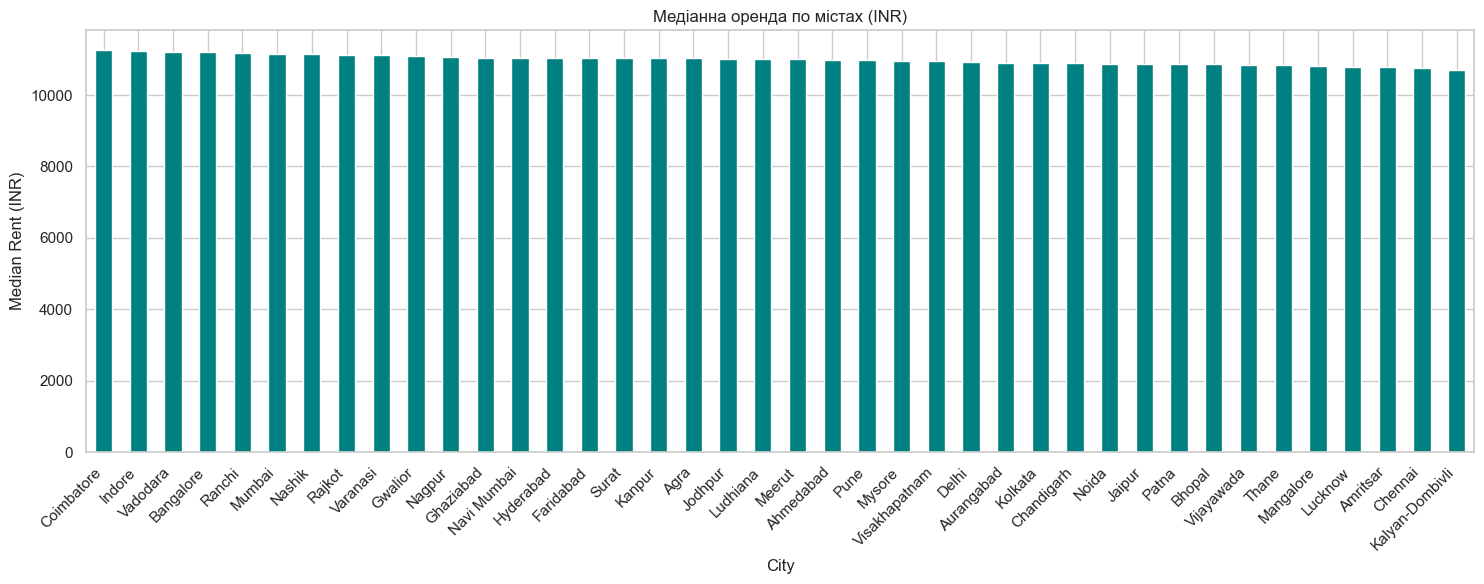

In [8]:
city_stats = df.groupby('City')['Rent'].median().sort_values(ascending=False)

plt.figure(figsize=(15, 6))
city_stats.plot(kind='bar', color='teal', edgecolor='white')
plt.title('Медіанна оренда по містах (INR)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Median Rent (INR)')
plt.tight_layout()
plt.savefig('../notebooks/rent_by_city.png', dpi=150)
plt.show()

## 5. Вплив BHK та площі на оренду

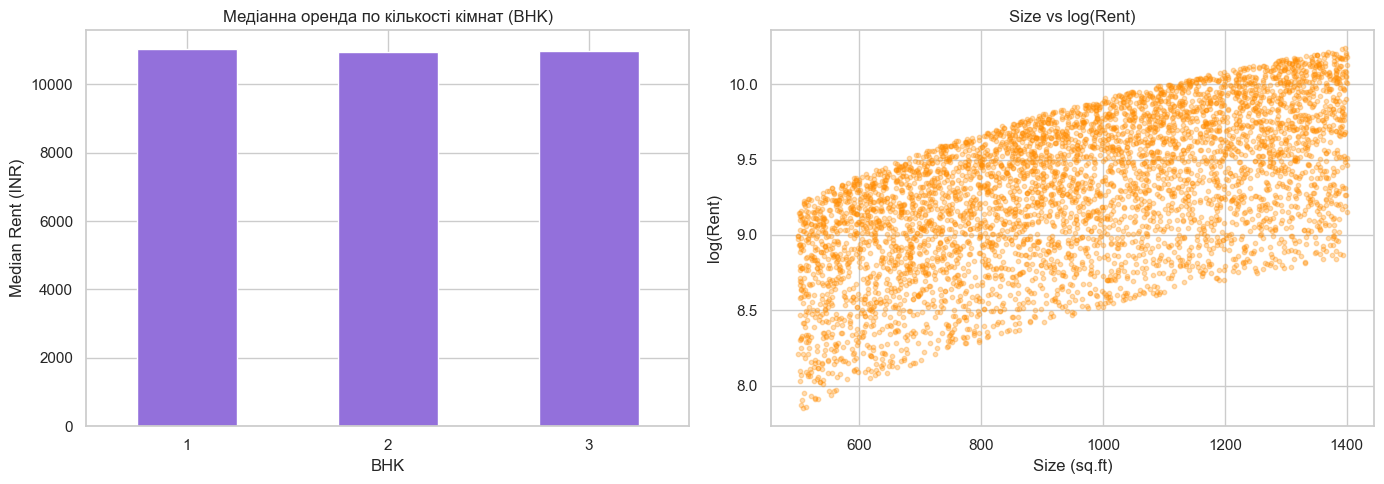

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BHK vs Rent
df_plot = df[df['BHK'].between(1, 6)]
df_plot.groupby('BHK')['Rent'].median().plot(kind='bar', ax=axes[0], color='mediumpurple', edgecolor='white')
axes[0].set_title('Медіанна оренда по кількості кімнат (BHK)')
axes[0].set_xlabel('BHK')
axes[0].set_ylabel('Median Rent (INR)')
axes[0].tick_params(axis='x', rotation=0)

# Scatter Size vs Rent
sample = df.sample(min(5000, len(df)), random_state=42)
axes[1].scatter(sample['Size'], np.log1p(sample['Rent']), alpha=0.3, color='darkorange', s=10)
axes[1].set_title('Size vs log(Rent)')
axes[1].set_xlabel('Size (sq.ft)')
axes[1].set_ylabel('log(Rent)')

plt.tight_layout()
plt.savefig('../notebooks/bhk_size_analysis.png', dpi=150)
plt.show()

## 6. Статус меблювання та тип орендаря

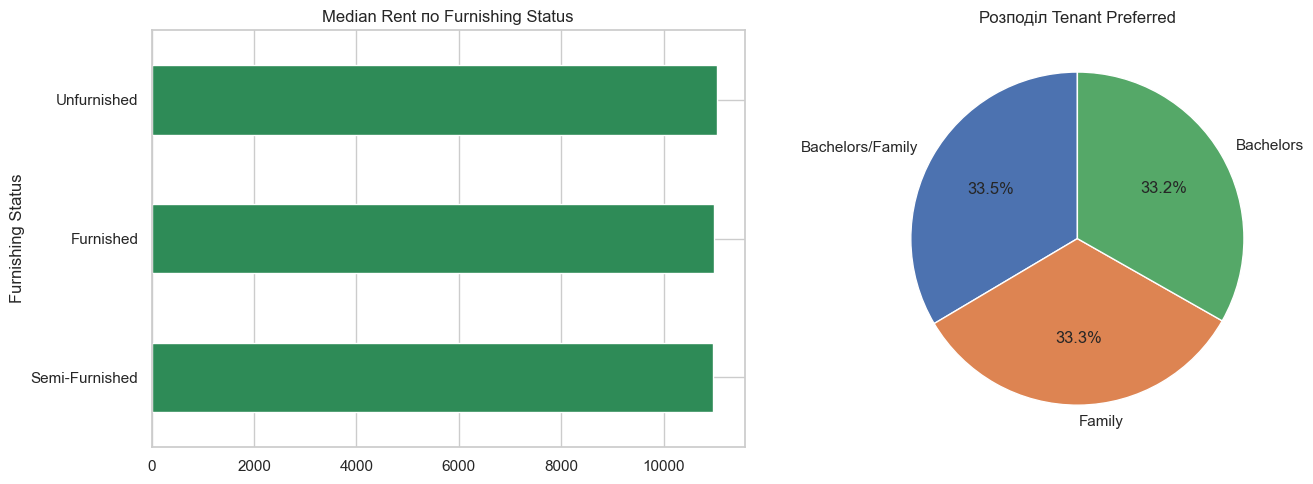

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('Furnishing Status')['Rent'].median().sort_values().plot(
    kind='barh', ax=axes[0], color='seagreen', edgecolor='white')
axes[0].set_title('Median Rent по Furnishing Status')

df['Tenant Preferred'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90,
    colors=['#4C72B0', '#DD8452', '#55A868'])
axes[1].set_title('Розподіл Tenant Preferred')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../notebooks/furnishing_tenant.png', dpi=150)
plt.show()

## 7. Матриця кореляції

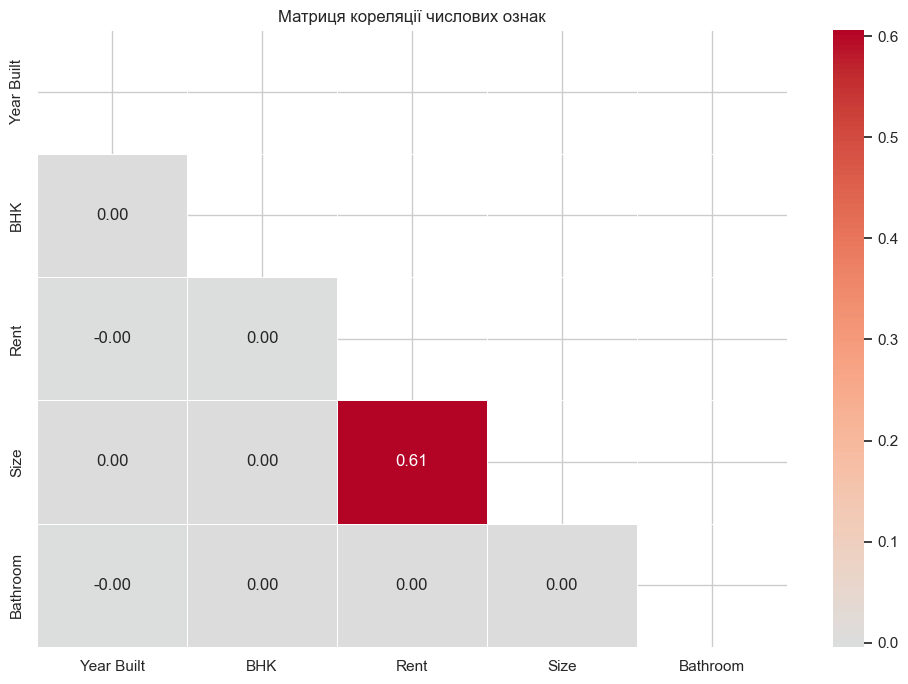

In [12]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Матриця кореляції числових ознак')
plt.tight_layout()
plt.savefig('../notebooks/correlation_matrix.png', dpi=150)
plt.show()

## 8. Висновки EDA

- **Rent** має сильний правосторонній скос → логарифмування допоможе моделі
- **Size** та **BHK** найбільше корелюють з орендою
- **Mumbai, Delhi, Bangalore** — найдорожчі міста
- **Furnished** апартаменти коштують значно дорожче за Unfurnished
- Є пропуски у колонці **Floor** — потрібна обробка
- **Building Type**, **Furnishing Status**, **City** — важливі категоріальні ознаки